In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import pandas as pd
from scipy.signal import find_peaks

In [7]:
# to load a csv file
ppg_green = pd.read_csv('1970-02-24_06-26-53-153836_PG.csv')

In [8]:
ppg_green # this is a dataframe
# we care about
# time column: LocalTimestamp
# ppg col: PG

,LocalTimestamp,EmotiBitTimestamp,PacketNumber,DataLength,TypeTag,ProtocolVersion,DataReliability,PG
0,4.717614e+06,1564368.000,48418,5,PG,1,100,3576
1,4.717614e+06,1564368.000,48418,5,PG,1,100,3631
2,4.717614e+06,1564368.000,48418,5,PG,1,100,3579
3,4.717614e+06,1564368.000,48418,5,PG,1,100,3610
4,4.717614e+06,1564368.000,48418,5,PG,1,100,3610
...,...,...,...,...,...,...,...,...
61114,4.718230e+06,2180612.222,16920,9,PG,1,100,168
61115,4.718230e+06,2180622.667,16920,9,PG,1,100,184
61116,4.718230e+06,2180633.111,16920,9,PG,1,100,166
61117,4.718230e+06,2180643.556,16920,9,PG,1,100,157


In [9]:
# to access a column
ppg_green['PG']


0        3576
1        3631
2        3579
3        3610
4        3610
         ... 
61114     168
61115     184
61116     166
61117     157
61118     179
Name: PG, Length: 61119, dtype: int64

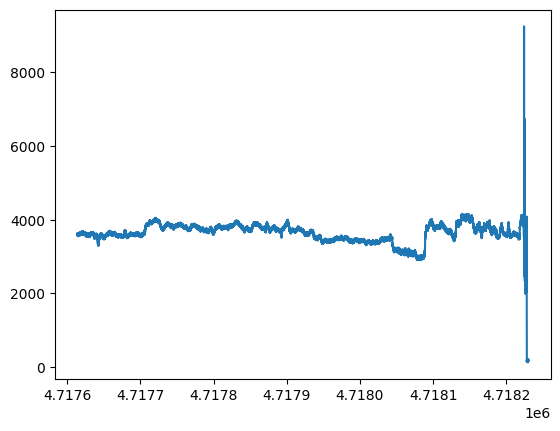

In [10]:
plt.plot(ppg_green['LocalTimestamp'], ppg_green['PG'])

In [11]:
import neurokit2 as nk

# Download example data
data = nk.data("bio_eventrelated_100hz")

# Preprocess the data (filter, find peaks, etc.)
processed_data, info = nk.bio_process(ecg=data["ECG"], rsp=data["RSP"], eda=data["EDA"], sampling_rate=100)

# Compute relevant features
results = nk.bio_analyze(processed_data, sampling_rate=100)

In [12]:
ppg = nk.ppg_simulate(duration=10, sampling_rate=1000, heart_rate=70)

In [13]:
signals, info = nk.ppg_process(ppg, sampling_rate=1000)

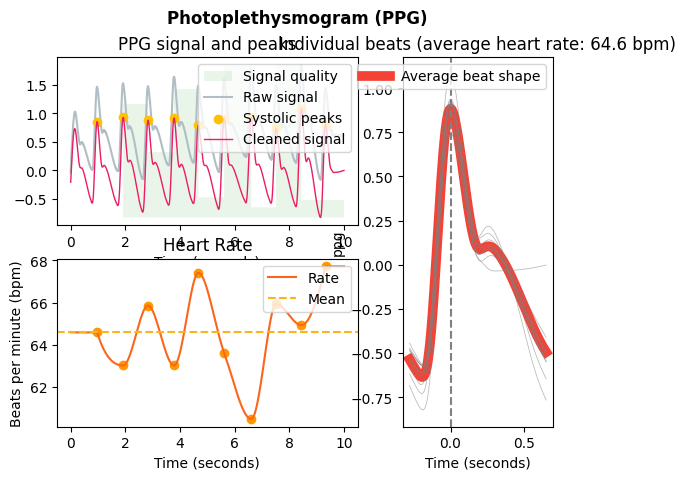

In [14]:
nk.ppg_plot(signals, info)

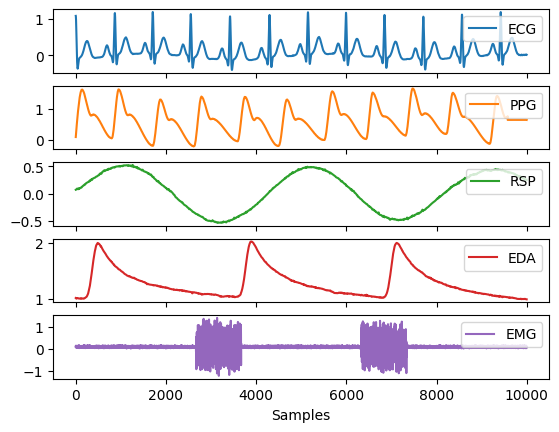

In [15]:

# Generate synthetic signals
ecg = nk.ecg_simulate(duration=10, heart_rate=70)
ppg = nk.ppg_simulate(duration=10, heart_rate=70)
rsp = nk.rsp_simulate(duration=10, respiratory_rate=15)
eda = nk.eda_simulate(duration=10, scr_number=3)
emg = nk.emg_simulate(duration=10, burst_number=2)

# Visualise biosignals
data = pd.DataFrame({"ECG": ecg,
                     "PPG": ppg,
                     "RSP": rsp,
                     "EDA": eda,
                     "EMG": emg})
nk.signal_plot(data, subplots=True)

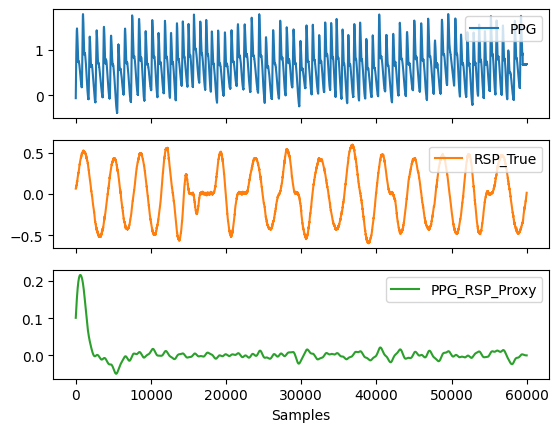

In [17]:
# Simulate signals
ppg = nk.ppg_simulate(duration=60, heart_rate=70)
rsp = nk.rsp_simulate(duration=60, respiratory_rate=15)
fs = 1000  # adjust if you set a different sampling rate

# Process PPG
ppg_signals, ppg_info = nk.ppg_process(ppg, sampling_rate=fs)

# Try to derive respiration from PPG
# One simple first-pass approach: smooth or low-pass the cleaned PPG signal
ppg_clean = ppg_signals["PPG_Clean"]

# Example: extract slow component
ppg_rsp = nk.signal_filter(ppg_clean, sampling_rate=fs, lowcut=0.1, highcut=0.4, method="butterworth", order=2)

# Detect peaks and troughs in the respiration proxy
peaks, _ = find_peaks(ppg_rsp, distance=fs*2)
troughs, _ = find_peaks(-ppg_rsp, distance=fs*2)

# Put in dataframe for plotting
data = pd.DataFrame({
    "PPG": ppg,
    "RSP_True": rsp,
    "PPG_RSP_Proxy": ppg_rsp
})

nk.signal_plot(data, subplots=True)